In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Exploration
### Q1: Initial Inspection
Write a Pandas script to load the `ev_charging_sessions.csv` file. Display its dimensions (total rows and columns) and print the first 5 rows to understand the structure of the data.

In [96]:
df =pd.read_csv("/Users/dipusardar/Dipu/Data-Analysis-Visualization-/Project 07/ev_charging_sessions.csv")
print('The Size of the data frame!')
print(df.shape)

print('=' * 100)
print('First 5 rows are...\n')
print(df.head(5))

The Size of the data frame!
(110, 8)
First 5 rows are...

  Session_ID Station_Location   Vehicle_Model  Battery_Capacity_kWh  \
0    CHG1000            Urban   Tesla Model 3                    75   
1    CHG1001          Highway   Tesla Model 3                    75   
2    CHG1002          Highway  Chevrolet Bolt                    66   
3    CHG1003         Suburban         VW ID.4                    82   
4    CHG1004            Urban         VW ID.4                    82   

   Energy_Consumed_kWh  Charging_Duration_mins  Cost_USD   User_Type  
0                62.21                   356.0     16.43  Subscriber  
1                39.37                    53.0     18.04  Subscriber  
2                26.09                    35.0     12.46      Casual  
3                49.37                   418.0     15.82      Casual  
4                56.83                   318.0     15.14  Subscriber  


### Q2: Schema and Completeness Check
Inspect the data types of each column to ensure they loaded correctly. Write code to count the number of missing (null) values present in each column of the dataset.

In [97]:
print('The data types are..')
print()
print(df.dtypes)
print('=' * 100)

print('Null values Check!')
print()
print(df.isnull().sum())

The data types are..

Session_ID                 object
Station_Location           object
Vehicle_Model              object
Battery_Capacity_kWh        int64
Energy_Consumed_kWh       float64
Charging_Duration_mins    float64
Cost_USD                  float64
User_Type                  object
dtype: object
Null values Check!

Session_ID                0
Station_Location          0
Vehicle_Model             0
Battery_Capacity_kWh      0
Energy_Consumed_kWh       6
Charging_Duration_mins    6
Cost_USD                  0
User_Type                 0
dtype: int64


## 2. Data Cleaning & Manipulation
### Q3: Imputation & Row Deletion
Handle the missing data using the following strategy:
1. Impute (fill) the missing values in the `Charging_Duration_mins` column with the **median** value of that specific column.
2. Permanently drop the rows where `Energy_Consumed_kWh` is missing from the dataset.
Verify that no null values remain after executing your solution.

In [98]:
print(df.columns)
print('+' * 100)
print(df.head(5))
print('+' * 100)
print(df.dtypes)



Index(['Session_ID', 'Station_Location', 'Vehicle_Model',
       'Battery_Capacity_kWh', 'Energy_Consumed_kWh', 'Charging_Duration_mins',
       'Cost_USD', 'User_Type'],
      dtype='object')
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Session_ID Station_Location   Vehicle_Model  Battery_Capacity_kWh  \
0    CHG1000            Urban   Tesla Model 3                    75   
1    CHG1001          Highway   Tesla Model 3                    75   
2    CHG1002          Highway  Chevrolet Bolt                    66   
3    CHG1003         Suburban         VW ID.4                    82   
4    CHG1004            Urban         VW ID.4                    82   

   Energy_Consumed_kWh  Charging_Duration_mins  Cost_USD   User_Type  
0                62.21                   356.0     16.43  Subscriber  
1                39.37                    53.0     18.04  Subscriber  
2                26.09                    35.0     12.46      Casu

In [99]:
# number 1 from the question number 03
#Get median first from the column
duration_median = df['Charging_Duration_mins'].median() #get median first

#Now fill with median
df['Charging_Duration_mins'] = df['Charging_Duration_mins'].fillna(duration_median) #fill with median 


In [100]:
print(df['Energy_Consumed_kWh'].isnull().any())
df = df.dropna(subset=['Energy_Consumed_kWh'])
print(df['Energy_Consumed_kWh'].isnull().any())

True
False


### Q4: Conditional Subsetting
Filter the cleaned DataFrame to extract rows where the charging session took place at a **'Highway'** station and the user was a **'Subscriber'**. Save this subset as a new variable and display its summary statistics.

In [101]:
print(df.columns)
print('+' * 100)

print('+' * 100)
filtered_dataframe = df[(df['Station_Location'] == 'Highway') & (df['User_Type'] == 'Subscriber')]
print(filtered_dataframe)

print('+' * 100)
print('+' * 100)
print(filtered_dataframe.describe())

Index(['Session_ID', 'Station_Location', 'Vehicle_Model',
       'Battery_Capacity_kWh', 'Energy_Consumed_kWh', 'Charging_Duration_mins',
       'Cost_USD', 'User_Type'],
      dtype='object')
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
   Session_ID Station_Location    Vehicle_Model  Battery_Capacity_kWh  \
1     CHG1001          Highway    Tesla Model 3                    75   
7     CHG1007          Highway          VW ID.4                    82   
9     CHG1009          Highway      Nissan Leaf                    40   
12    CHG1012          Highway   Chevrolet Bolt                    66   
25    CHG1025          Highway  Hyundai Ioniq 5                    77   
33    CHG1033          Highway          VW ID.4                    82   
34    CHG1034          Highway   Chevrolet Bolt                    66   
35    CHG1035        

### Q5: Feature Engineering & Sorting
Create a new column named `Charging_Speed_kW` which calculates the rate of energy delivery per hour. Use the formula:
$$\text{Charging\_Speed\_kW} = \left(\frac{\text{Energy\_Consumed\_kWh}}{\text{Charging\_Duration\_mins}}\right) \times 60$$
Once the column is created, sort the entire DataFrame by `Charging_Speed_kW` in **descending order** and display the top 5 fastest sessions.


In [102]:
#Making new column
df['Charging_Speed_KW'] = (df['Energy_Consumed_kWh'] / df['Charging_Duration_mins']) * 60

In [103]:
df = df.sort_values(by='Charging_Speed_KW' , ascending=False)
print(df.head(5))

    Session_ID Station_Location    Vehicle_Model  Battery_Capacity_kWh  \
12     CHG1012          Highway   Chevrolet Bolt                    66   
67     CHG1067          Highway  Hyundai Ioniq 5                    77   
94     CHG1094          Highway  Hyundai Ioniq 5                    77   
75     CHG1075          Highway          VW ID.4                    82   
107    CHG1107          Highway      Nissan Leaf                    40   

     Energy_Consumed_kWh  Charging_Duration_mins  Cost_USD   User_Type  \
12                 23.35                    26.0     11.31  Subscriber   
67                 54.70                    68.0     24.47  Subscriber   
94                 63.11                    79.0     28.01  Subscriber   
75                 50.95                    64.0     22.90  Subscriber   
107                20.63                    26.0     10.16      Casual   

     Charging_Speed_KW  
12           53.884615  
67           48.264706  
94           47.931646  
75        

## 3. Mathematical & Statistical Analysis
### Q6: Central Tendency and Dispersion
Use NumPy or Pandas functions to compute the **mean**, **median**, and **standard deviation** of the `Cost_USD` column. Round your results to two decimal places.

In [104]:
print('Find the mean.')
print(round(df['Cost_USD'].mean(), 2))
print('=' * 100)

print('Find the median.')
print(round(df['Cost_USD'].median(), 2))
print('=' * 100)

print('Find the STD.')
print(round(df['Cost_USD'].std(), 2))




Find the mean.
13.7
Find the median.
13.0
Find the STD.
5.36


### Q7: Aggregated Metrics
Group the dataset by `Vehicle_Model`. Calculate the **total energy consumed** (`Energy_Consumed_kWh`) and the **total revenue generated** (`Cost_USD`) for each vehicle model.

In [105]:
print(df.columns)
print('=' * 100)

group = df.groupby(df['Vehicle_Model']).agg({
    'Energy_Consumed_kWh' : 'sum', 
    'Cost_USD' : 'sum'
})

print(group)




Index(['Session_ID', 'Station_Location', 'Vehicle_Model',
       'Battery_Capacity_kWh', 'Energy_Consumed_kWh', 'Charging_Duration_mins',
       'Cost_USD', 'User_Type', 'Charging_Speed_KW'],
      dtype='object')
                 Energy_Consumed_kWh  Cost_USD
Vehicle_Model                                 
Chevrolet Bolt                964.65    312.80
Hyundai Ioniq 5               906.54    309.11
Nissan Leaf                   524.42    196.55
Tesla Model 3                 901.83    313.06
VW ID.4                       896.57    293.10


### Q8: Correlation Analysis
Use the appropriate Pandas function to determine the Pearson correlation coefficient between `Battery_Capacity_kWh` and `Energy_Consumed_kWh`. Explain briefly what this coefficient indicates about the relationship between a vehicle's battery capacity and the energy drawn.

In [106]:
correlation_values = df['Battery_Capacity_kWh'].corr(df['Energy_Consumed_kWh'])
print(f'Person Correlation Coefficient: {correlation_values:.4f}')

Person Correlation Coefficient: 0.6614


## 4. Data Visualization
### Q9: Categorical Comparison (Bar Plot)
Using Matplotlib and Seaborn, create a bar plot showing the **average cost** (`Cost_USD`) across the three different `Station_Location` types ('Urban', 'Suburban', 'Highway'). Customize your plot by adding an informative title, distinct axis labels, and a professional, clean color palette (e.g., `'muted'` or `'viridis'`).

/var/folders/d7/qnjhd31d2r3dm1cfb2qrw7xm0000gn/T/ipykernel_1081/1732813168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


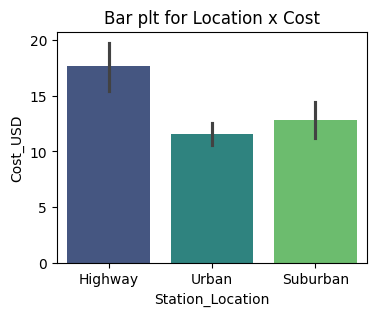

In [107]:
plt.figure(figsize=(4,3))
sns.barplot(
    data=df,
    x='Station_Location',
    y='Cost_USD', 
    palette='viridis'
)
plt.title('Bar plt for Location x Cost')
plt.show()

### Q10: Bivariate Relationship (Scatter Plot)
Construct a scatter plot using Seaborn to map the relationship between `Charging_Duration_mins` (X-axis) and `Energy_Consumed_kWh` (Y-axis). Use the `hue` parameter to color-code the points based on `User_Type` ('Subscriber' vs. 'Casual'). Add appropriate titles and gridlines to make the chart ready for a business presentation.


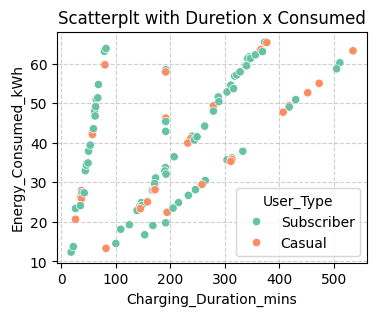

In [108]:
plt.figure(figsize=(4,3))

sns.scatterplot(
    data=df,
    x='Charging_Duration_mins',
    y='Energy_Consumed_kWh',
    hue='User_Type',
    palette='Set2'
)
plt.title('Scatterplt with Duretion x Consumed')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class EVSmartPipeline:
    """
    EV Charging ডাটাসেটের ডাটা প্রসেস, ফিচার ইঞ্জিনিয়ারিং এবং 
    ভিজ্যুয়ালাইজেশনের জন্য একটি প্রফেশনাল ওওপি পাইপলাইন।
    """
    
    def __init__(self, file_path: str):
        self.file_path = '/Users/dipusardar/Dipu/Data-Analysis-Visualization-/Project 07/ev_charging_sessions.csv'
        self._df = None  # ডাটাফ্রেম এনক্যাপসুলেশন
        
    def load_and_clean_data(self) -> pd.DataFrame:
        """ধাপ ১: ডাটা লোড করে নাল ভ্যালু ক্লিন করা"""
        # ডাটা লোড
        self._df = pd.read_csv(self.file_path)
        print(f"[১/৪] ডাটা লোড সম্পন্ন। প্রাথমিক সারি: {len(self._df)}")
        
        # ১. Charging_Duration_mins এর নাল ভ্যালু মিডিয়ান দিয়ে পূরণ
        duration_median = self._df['Charging_Duration_mins'].median()
        self._df['Charging_Duration_mins'] = self._df['Charging_Duration_mins'].fillna(duration_median)
        
        # ২. Energy_Consumed_kWh এর নাল ভ্যালুযুক্ত সারি ড্রপ
        self._df = self._df.dropna(subset=['Energy_Consumed_kWh'])
        print(f"[২/৪] ডাটা ক্লিনিং সম্পন্ন। বর্তমান সারি: {len(self._df)}")
        return self._df
        
    def build_features(self) -> None:
        """ধাপ ২: ফিচার ইঞ্জিনিয়ারিং (নতুন কলাম তৈরি)"""
        if self._df is None:
            raise ValueError("পাইপলাইনে কোনো ডাটা নেই! আগে load_and_clean_data() কল করুন।")
            
        # প্রতি ঘণ্টার চার্জিং স্পিড (kW) বের করার সূত্র
        self._df['Charging_Speed_kW'] = (self._df['Energy_Consumed_kWh'] / self._df['Charging_Duration_mins']) * 60
        print("[৩/৪] ফিচার ইঞ্জিনিয়ারিং সম্পন্ন। 'Charging_Speed_kW' কলাম যুক্ত হয়েছে।")
        
    def generate_scatter_plot(self, output_filename: str = 'ev_scatter_plot.png') -> None:
        """ধাপ ৩: বিচিত্র অ্যানালিসিস এবং গ্রাফ তৈরি করা (Q10 এর ওওপি রূপ)"""
        if self._df is None:
            raise ValueError("ভিজ্যুয়ালাইজেশনের জন্য কোনো ডাটা পাওয়া যায়নি।")
            
        plt.figure(figsize=(8, 5))
        sns.set_theme(style="whitegrid")
        
        # স্ক্যাটার প্লট অঙ্কন
        sns.scatterplot(
            x='Charging_Duration_mins',
            y='Energy_Consumed_kWh',
            hue='User_Type',
            data=self._df,
            palette='Set1',
            s=70,  # ডটের সাইজ
            alpha=0.8
        )
        
        # গ্রাফের সাজসজ্জা
        plt.title('Energy Consumed vs. Charging Duration (OOP Pipeline)', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Charging Duration (Minutes)', fontsize=11)
        plt.ylabel('Energy Consumed (kWh)', fontsize=11)
        plt.legend(title='User Type')
        plt.tight_layout()
        
        # গ্রাফটি ইমেজ হিসেবে হার্ডডিস্কে সেভ করা (ইন্ডাস্ট্রি স্ট্যান্ডার্ড প্র্যাকটিস)
        plt.savefig(output_filename, dpi=300)
        print(f"[৪/৪] ভিজ্যুয়ালাইজেশন সম্পন্ন! গ্রাফটি '{output_filename}' নামে সেভ হয়েছে।")
        plt.show()
        
    def show_top_fastest_sessions(self, top_n: int = 5):
        """ধাপ ৪: দ্রুততম সেশনগুলোর রিপোর্ট দেখা (Q5 এর ওওপি রূপ)"""
        print(f"\n--- শীর্ষ {top_n}টি দ্রুততম চার্জিং সেশন ---")
        sorted_df = self._df.sort_values(by='Charging_Speed_kW', ascending=False)
        return sorted_df[['Session_ID', 'Vehicle_Model', 'Charging_Speed_kW', 'Station_Location']].head(top_n)

[১/৪] ডাটা লোড সম্পন্ন। প্রাথমিক সারি: 110
[২/৪] ডাটা ক্লিনিং সম্পন্ন। বর্তমান সারি: 104
[৩/৪] ফিচার ইঞ্জিনিয়ারিং সম্পন্ন। 'Charging_Speed_kW' কলাম যুক্ত হয়েছে।
[৪/৪] ভিজ্যুয়ালাইজেশন সম্পন্ন! গ্রাফটি 'ev_scatter_plot.png' নামে সেভ হয়েছে।


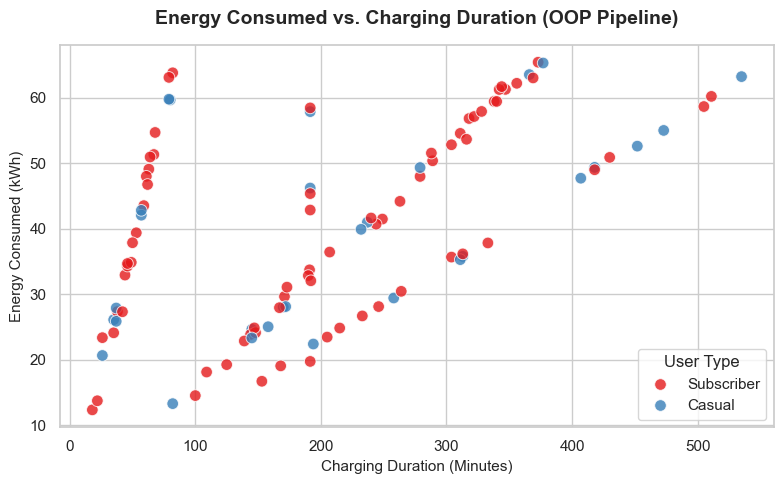


--- শীর্ষ 5টি দ্রুততম চার্জিং সেশন ---


,Session_ID,Vehicle_Model,Charging_Speed_kW,Station_Location
12,CHG1012,Chevrolet Bolt,53.884615,Highway
67,CHG1067,Hyundai Ioniq 5,48.264706,Highway
94,CHG1094,Hyundai Ioniq 5,47.931646,Highway
75,CHG1075,VW ID.4,47.765625,Highway
107,CHG1107,Nissan Leaf,47.607692,Highway


In [111]:
# পাইপলাইনের একটি ইনস্ট্যান্স/অবজেক্ট তৈরি করা
ev_analyst = EVSmartPipeline(file_path='ev_charging_sessions.csv')

# মেথডগুলোকে চেইন আকারে একটার পর একটা এক্সিকিউট করা
ev_analyst.load_and_clean_data()
ev_analyst.build_features()

# সরাসরি গ্রাফ আউটপুট দেখা এবং সেভ করা
ev_analyst.generate_scatter_plot()

# দ্রুততম ৫টি সেশনের টেবিল দেখা
ev_analyst.show_top_fastest_sessions(top_n=5)